In [2]:
pip install --upgrade pyarrow pandas

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
chunks = []
for chunk in pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1",
                          chunksize=100000, dtype={"Customer ID": str}):
    chunks.append(chunk)
 
df = pd.concat(chunks, ignore_index=True)
print(f"loaded {len(df):,} rows")

loaded 1,067,371 rows


In [20]:
df.dropna(subset=["Customer ID"], inplace=True)
 
# invoices starting with C are cancellations, removing them
df = df[~df["Invoice"].astype(str).str.startswith("C")]
 
# negative quantities and prices don't make sense for sales data
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
 
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["Price"]
 
print(f"after cleaning: {len(df):,} rows, {df['Customer ID'].nunique():,} unique customers")
print(f"date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
 

after cleaning: 805,549 rows, 5,878 unique customers
date range: 2009-12-01 to 2011-12-09


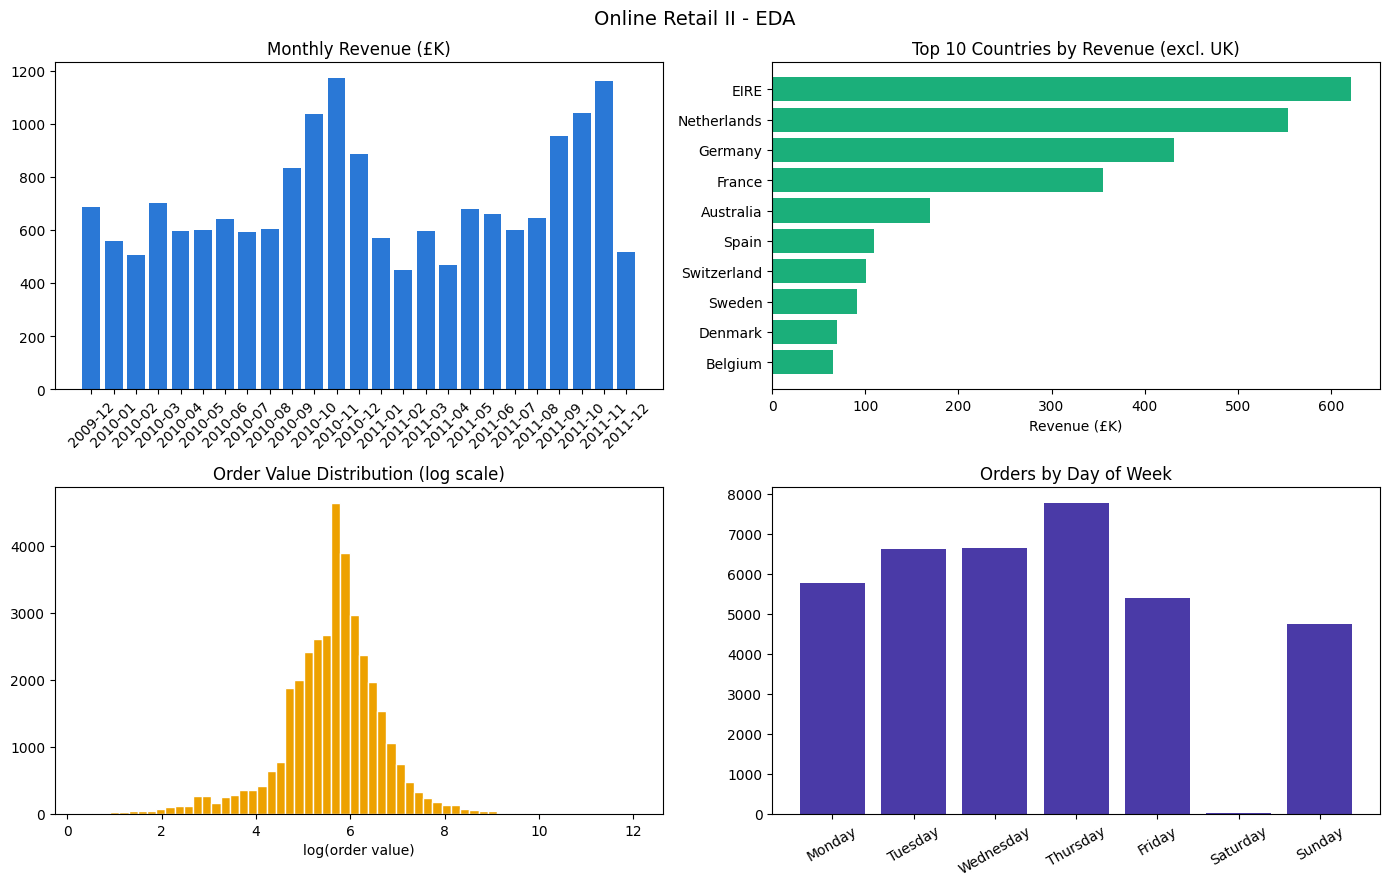

In [21]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_rev = df.groupby("YearMonth")["TotalAmount"].sum()
 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Online Retail II - EDA", fontsize=14)
 
# monthly revenue
axes[0, 0].bar(monthly_rev.index.astype(str), monthly_rev.values / 1000, color="#2a78d6")
axes[0, 0].set_title("Monthly Revenue (£K)")
axes[0, 0].tick_params(axis="x", rotation=45)
 
# top countries excluding UK since it completely dominates the data
country_rev = (df[df["Country"] != "United Kingdom"]
               .groupby("Country")["TotalAmount"].sum()
               .sort_values(ascending=False).head(10))
axes[0, 1].barh(country_rev.index[::-1], country_rev.values[::-1] / 1000, color="#1baf7a")
axes[0, 1].set_title("Top 10 Countries by Revenue (excl. UK)")
axes[0, 1].set_xlabel("Revenue (£K)")
 
# order value distribution - using log because the data is very skewed
order_vals = df.groupby("Invoice")["TotalAmount"].sum()
axes[1, 0].hist(np.log1p(order_vals), bins=60, color="#eda100", edgecolor="white")
axes[1, 0].set_title("Order Value Distribution (log scale)")
axes[1, 0].set_xlabel("log(order value)")
 
# which days have the most orders
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
day_counts = df.groupby("DayOfWeek")["Invoice"].nunique().reindex(day_order)
axes[1, 1].bar(day_counts.index, day_counts.values, color="#4a3aa7")
axes[1, 1].set_title("Orders by Day of Week")
axes[1, 1].tick_params(axis="x", rotation=30)
 
plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
 

In [22]:
 
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
 
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()
 
# scoring each metric 1-4, recency is reversed (lower days = better score)
rfm["R"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["rfm_score"] = rfm["R"].astype(int) + rfm["F"].astype(int) + rfm["M"].astype(int)
 
def label_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal"
    elif score >= 6:
        return "Potential"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"
 
rfm["Segment"] = rfm["rfm_score"].apply(label_segment)
print("\nCustomer segments:")
print(rfm["Segment"].value_counts())


Customer segments:
Segment
Champions    1738
Potential    1220
Loyal        1190
At Risk      1155
Lost          575
Name: count, dtype: int64


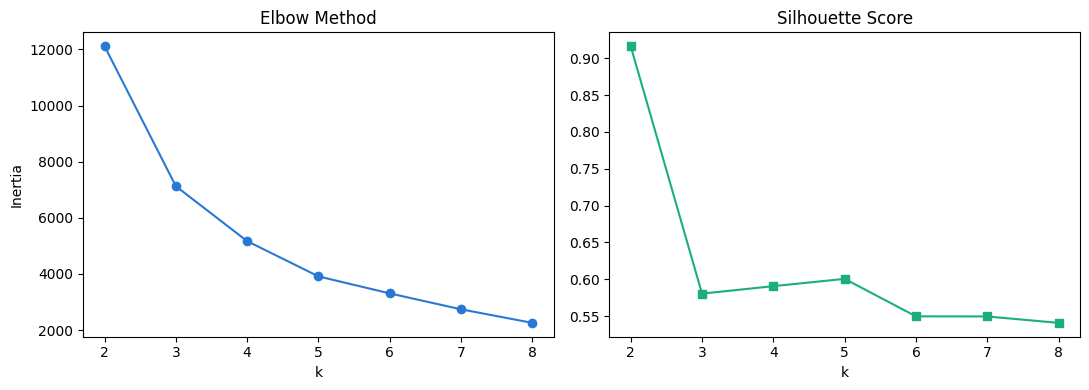


Cluster profiles:
         Recency  Frequency  Monetary
Cluster                              
0          463.0        2.2     765.2
1           67.0        7.3    3009.4
2           25.9      103.7   83086.1
3            3.5      212.5  436835.8


In [23]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
 
# checking elbow + silhouette to pick the right k
inertia, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(range(2, 9), inertia, marker="o", color="#2a78d6")
ax1.set_title("Elbow Method")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
 
ax2.plot(range(2, 9), sil_scores, marker="s", color="#1baf7a")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("k")
plt.tight_layout()
plt.savefig("elbow.png", dpi=150, bbox_inches="tight")
plt.show()
 
# k=4 worked well based on the elbow + silhouette, adjust if needed
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = km_final.fit_predict(rfm_scaled)
 
print("\nCluster profiles:")
print(rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1))

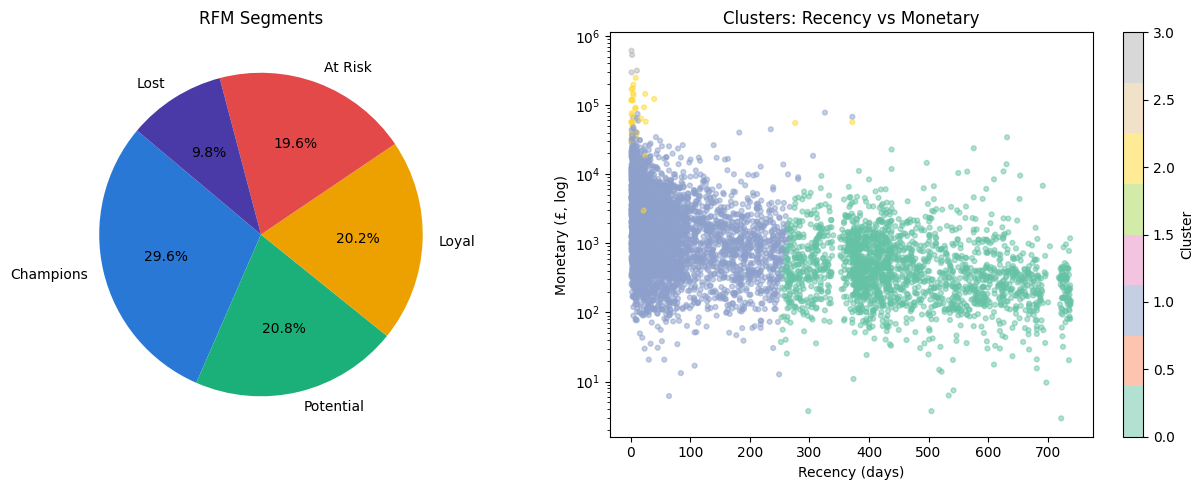

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
 
seg_counts = rfm["Segment"].value_counts()
ax1.pie(seg_counts.values, labels=seg_counts.index,
        colors=["#2a78d6", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"],
        autopct="%1.1f%%", startangle=140)
ax1.set_title("RFM Segments")
 
sc = ax2.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"],
                 cmap="Set2", alpha=0.5, s=12)
ax2.set_yscale("log")
ax2.set_title("Clusters: Recency vs Monetary")
ax2.set_xlabel("Recency (days)")
ax2.set_ylabel("Monetary (£, log)")
plt.colorbar(sc, ax=ax2, label="Cluster")
 
plt.tight_layout()
plt.savefig("segments.png", dpi=150, bbox_inches="tight")
plt.show()

